# Qwen3-VL-Embedding-8B でメッセージのembeddingを生成

このノートブックでは、traQのメッセージからテキストと画像を抽出し、Qwen3-VL-Embedding-8Bモデルでembeddingを生成します。


In [21]:
# 必要なパッケージのインストール
%pip install "transformers>=4.57.0" accelerate "torch==2.8.0" pillow requests python-dotenv numpy scikit-learn matplotlib seaborn "qwen-vl-utils>=0.0.14"  -q

# 公式のQwen3VLEmbedderクラスをインストール
!mkdir -p scripts
!wget -q https://huggingface.co/Qwen/Qwen3-VL-Embedding-8B/resolve/main/scripts/qwen3_vl_embedding.py -O scripts/qwen3_vl_embedding.py

In [22]:
import torch
import gc

# メモリをクリア
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")


PyTorch version: 2.9.0+cu126
CUDA available: True
CUDA device: NVIDIA A100-SXM4-80GB
GPU Memory: 79.32 GB


In [23]:
import requests
import os 
import re
import io
from PIL import Image


messageIds = [
    "019b2a64-eebc-7815-84c5-e384fabc495c", #ictトラブルシューティング予選結果
    "019a48ff-b175-783c-93fc-b4ec6731dde5", #TechBookの販売記録
    "019bb6b8-5c57-7d1f-8b93-297c8e6c7827", #ポータブルモニターを購入
    "019bb5c0-5409-7b3b-ba9b-07449030364a", #大学の課題の締め切り
    "019bd043-d86c-79b8-9cf1-11351a482267", #pcの空き容量の画像
    "0197c4ef-8be2-792e-922b-c498b6948775", #traqの9点リーダーのアイコン
    "01963951-0f55-75b5-a53b-07f467ad9051", #sysad体験会
    "0195be37-dea6-7902-8d04-e46185873108", #githubへの招待
    "019bde55-0ca0-7d7a-95ab-0a1c3bf5eeaa", #僕のgithub
    "019bde55-b166-7d7b-b290-2f049f72fe08", #googleの検索画面
    "019bbd0d-5e27-77b2-8494-42499697c033", #大学の課題をやろうとしてる。reportのpdf画像　やるぞ～と言ってる
    "019bde84-1609-7dc5-b8fc-f2c77bcdb005", #食べ物の画像すき焼き弁当
]



def _get_session() -> requests.Session:
    r_session = os.getenv("r_session")
    if not r_session:
        raise RuntimeError("r_session が見つかりません（環境変数を設定してください）")
    
    session = requests.Session()
    session.cookies.set("r_session", r_session)
    return session


# messageidの配列を受け取り、メッセージの配列を返す
def get_messages_and_images():
    BASE_URL = "https://q.trap.jp/api/v3"
    _FILE_URL_RE = re.compile(r"https?://q\.trap\.jp/files/([0-9a-fA-F-]+)")
    
    messages_result = []
    images_result = []
    
    with _get_session() as session:
        for message_id in messageIds:
            
            try:
                response = session.get(f"{BASE_URL}/messages/{message_id}")
                response.raise_for_status()
                content = response.json()["content"]

                """
                画像のurlを抽出
                メッセージのcontentからファイルIDを抽出
                画像はcontentの中にhttps://q.trap.jp/files/019b2a64-ee12-7815-9d3c-4c510250218aのような形式で保存されている
                """
                image_file_ids = _FILE_URL_RE.findall(content)

                imgs = []

                for image_file_id in image_file_ids:
                    response = session.get(f"{BASE_URL}/files/{image_file_id}")
                    response.raise_for_status()
                    img_bytes = response.content
                    pil_img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
                    imgs.append(pil_img)


                # content内にある 画像のurlを削除 (embeddingにurlは不要なため)
                processed_text = _FILE_URL_RE.sub("", content).strip()

                messages_result.append(processed_text)
                images_result.append(imgs)
            except requests.exceptions.RequestException as e:
                print(f"Error fetching message {message_id}: {e}")
    
    return messages_result, images_result


In [24]:
# traQ APIのセッション情報を設定
# vscodeだと.envが使えない？
import os

r_session = input("r_sessionを入力してください: ").strip()
if r_session:
    os.environ["r_session"] = r_session
    print("r_sessionを設定しました")
else:
    print("警告: r_sessionが設定されていません")

r_sessionを設定しました


## モデルのロード

最初にモデルをロードします。これには5.5分程度かかる場合があります。


In [25]:
from scripts.qwen3_vl_embedding import Qwen3VLEmbedder
import torch

model_name_or_path = "Qwen/Qwen3-VL-Embedding-8B"

model = Qwen3VLEmbedder(
    model_name_or_path=model_name_or_path,
    torch_dtype=torch.float16,
    # attn_implementation="flash_attention_2",　これがあるとうまくいかない
)

print("model loaded")



Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/784 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

model loaded


## メッセージの取得とembedding生成

メッセージを取得して、それぞれのembeddingを生成します。


In [26]:
# メッセージと画像を取得
messages, images = get_messages_and_images()
print(f"取得したメッセージ数: {len(messages)}")
print(f"画像ありメッセージ数: {sum(1 for imgs in images if len(imgs) > 0)}")

# Qwen3VLEmbedder 用の入力を作成
documents = []
for idx, (text, imgs) in enumerate(zip(messages, images)):
    # 複数画像がある場合は、各画像ごとにテキスト+画像の組み合わせを作成
    for img in imgs:
        documents.append({"text": text, "image": img})

print(f"入力数: {len(documents)}")

取得したメッセージ数: 12
画像ありメッセージ数: 12
入力数: 16


In [ ]:
# embeddingを生成
import os

os.makedirs("out", exist_ok=True)

# queriesは辞書形式に
query_texts = [
    "github",
    "pc",
    "モニター",
    "TechBook",
    "SysAd",
    "新入生",
    "テスト",
    "紙",
    "mumumu",
    "google",
    "googleのロゴが左上にありqwen3-vlについて検索してる",
    "大学の課題をやろうとしてる",
    "やる気がある",
    "ごはん",
    "駅弁",
    "すきやき"
]

# 辞書形式に変換
queries = [{"text": q} for q in query_texts]

inputs = queries + documents

print("embedding を生成中...")
print(f"  クエリ数: {len(queries)}")
print(f"  ドキュメント数: {len(documents)}")
print(f"  合計: {len(inputs)}")

embeddings = model.process(inputs)

# クエリとドキュメントの類似度を計算
num_queries = len(queries)
similarity_scores = (embeddings[:num_queries] @ embeddings[num_queries:].T)
print(f"\n類似度スコア shape: {similarity_scores.shape}")
print(similarity_scores.tolist())


embedding を生成中...
  クエリ数: 16
  ドキュメント数: 16
  合計: 32

類似度スコア shape: torch.Size([16, 16])
[[0.307861328125, 0.218017578125, 0.1827392578125, 0.27294921875, 0.2408447265625, 0.277099609375, 0.2447509765625, 0.30322265625, 0.27734375, 0.269775390625, 0.281982421875, 0.465087890625, 0.45361328125, 0.340087890625, 0.239013671875, -0.03582763671875], [0.2479248046875, 0.2457275390625, 0.289306640625, 0.320068359375, 0.2078857421875, 0.279296875, 0.2900390625, 0.2303466796875, 0.25146484375, 0.246337890625, 0.2484130859375, 0.224609375, 0.2227783203125, 0.27099609375, 0.19384765625, -0.0206756591796875], [0.254150390625, 0.313720703125, 0.45263671875, 0.4521484375, 0.257080078125, 0.29443359375, 0.299072265625, 0.26513671875, 0.318115234375, 0.327880859375, 0.308837890625, 0.241943359375, 0.2261962890625, 0.394775390625, 0.2315673828125, 0.00630950927734375], [0.250244140625, 0.443603515625, 0.2225341796875, 0.259765625, 0.1707763671875, 0.2109375, 0.2152099609375, 0.2249755859375, 0.306396484

In [ ]:
# 類似度マトリックスの可視化
import numpy as np
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# documentsのembeddingだけを取得（queriesは除外）
num_queries = len(queries)
documents_embeddings = embeddings[num_queries:]

print(f"Documents数: {len(documents_embeddings)}")
print(f"Embedding次元数: {documents_embeddings.shape[1]}")

# 類似度マトリックスを計算
print("\n類似度マトリックスを計算中...")
similarity_matrix = cosine_similarity(documents_embeddings.cpu().numpy())

print(f"類似度マトリックスの形状: {similarity_matrix.shape}")
print(f"類似度の範囲: min={similarity_matrix.min():.4f}, max={similarity_matrix.max():.4f}")
print(f"平均類似度: {similarity_matrix.mean():.4f}")

# ラベルを作成（メッセージインデックス + 画像数）
labels = []
for idx, (text, imgs) in enumerate(zip(messages, images)):
    img_count = len(imgs)
    if img_count == 0:
        labels.append(f"M{idx+1}")
    else:
        # 複数画像がある場合は、各画像ごとにラベルを作成
        for img_idx in range(img_count):
            labels.append(f"M{idx+1}-I{img_idx+1}")

print(f"\nラベル数: {len(labels)}")


Documents数: 16
Embedding次元数: 4096

類似度マトリックスを計算中...
類似度マトリックスの形状: (16, 16)
類似度の範囲: min=-0.0022, max=1.0000
平均類似度: 0.3449

ラベル数: 16


In [41]:
# ヒートマップで可視化
import warnings

# 日本語フォントの設定（Google Colab用）
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-noto-cjk'], capture_output=True)

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager

# フォントキャッシュをクリアして再構築
font_manager.fontManager.addfont('/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc')
matplotlib.rcParams['font.family'] = 'Noto Sans CJK JP'

# フォント関連の警告を抑制
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

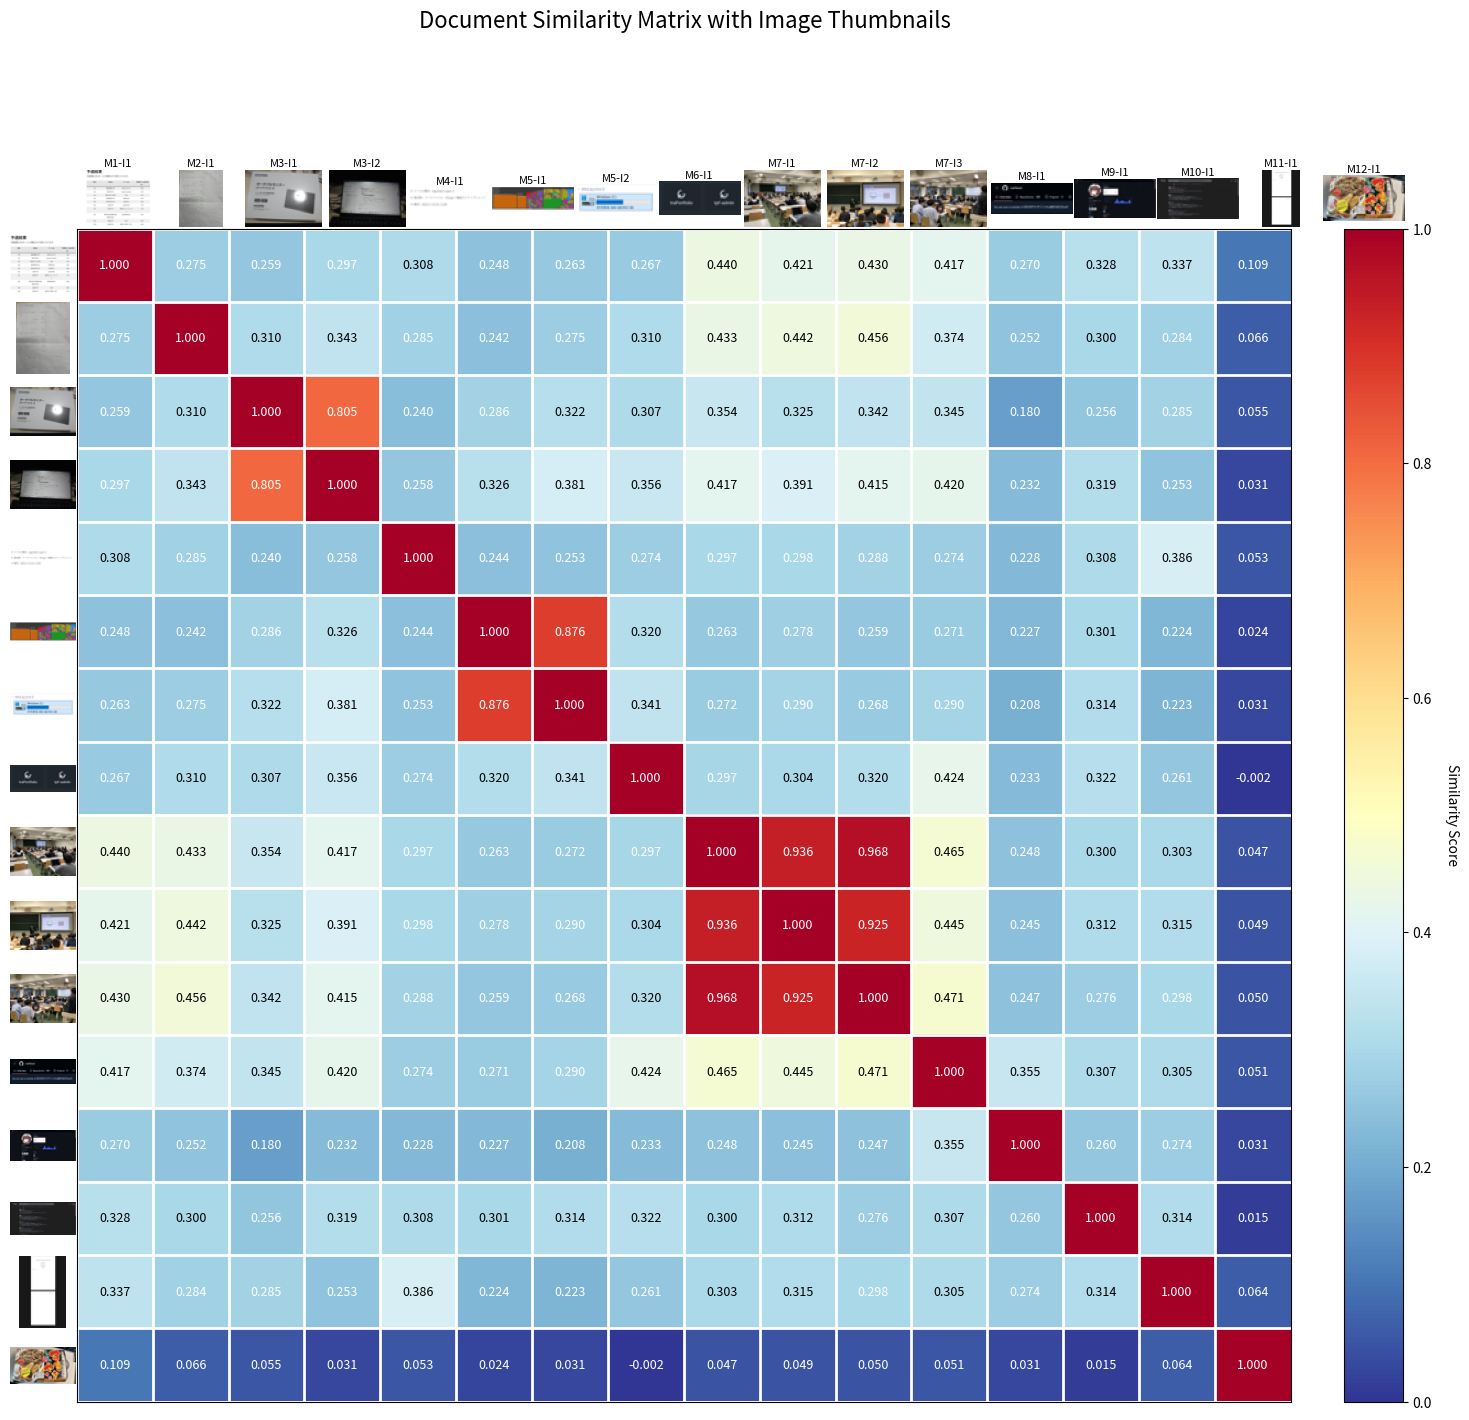

In [42]:
# 画像サムネイル付きヒートマップ（messages.pyの実装を参考）
import matplotlib.gridspec as gridspec
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# 画像サムネイルを準備
thumbnails = []
for idx, (text, imgs) in enumerate(zip(messages, images)):
    if imgs:
        for img in imgs:
            # サムネイルサイズにリサイズ（コピーを作成）
            thumb = img.copy()
            thumb.thumbnail((60, 60))
            thumbnails.append(np.array(thumb))
    else:
        # 画像がない場合は空の画像を作成
        thumbnails.append(np.ones((60, 60, 3), dtype=np.uint8) * 200)

num_docs = len(documents_embeddings)

# グリッドスペックを使用してレイアウトを作成
fig_img = plt.figure(figsize=(18, 16))
gs = gridspec.GridSpec(
    num_docs + 1, num_docs + 1,
    figure=fig_img,
    width_ratios=[0.8] + [1] * num_docs,
    height_ratios=[0.8] + [1] * num_docs,
    hspace=0.02, wspace=0.02
)

# 左上の空白
ax_corner = fig_img.add_subplot(gs[0, 0])
ax_corner.axis('off')

# 上部の画像（列ラベル）
for i in range(num_docs):
    ax_top = fig_img.add_subplot(gs[0, i + 1])
    ax_top.imshow(thumbnails[i])
    ax_top.axis('off')
    ax_top.set_title(labels[i], fontsize=8, pad=2)

# 左側の画像（行ラベル）
for i in range(num_docs):
    ax_left = fig_img.add_subplot(gs[i + 1, 0])
    ax_left.imshow(thumbnails[i])
    ax_left.axis('off')
    ax_left.set_ylabel(labels[i], fontsize=8, rotation=0, labelpad=10)

# ヒートマップのメイン部分
ax_main = fig_img.add_subplot(gs[1:, 1:])

# ヒートマップを描画
im = ax_main.imshow(
    similarity_matrix,
    cmap='RdYlBu_r',
    vmin=0,
    vmax=1,
    aspect='auto'
)

# 各セルに数値を表示
for i in range(num_docs):
    for j in range(num_docs):
        text_color = "black" if 0.3 < similarity_matrix[i, j] < 0.7 else "white"
        ax_main.text(
            j, i, f'{similarity_matrix[i, j]:.3f}',
            ha="center", va="center",
            color=text_color,
            fontsize=9
        )

# グリッド線を追加
ax_main.set_xticks(np.arange(num_docs) - 0.5, minor=True)
ax_main.set_yticks(np.arange(num_docs) - 0.5, minor=True)
ax_main.grid(which="minor", color="white", linestyle='-', linewidth=2)
ax_main.tick_params(which="minor", size=0)

# メジャーティックを非表示
ax_main.set_xticks([])
ax_main.set_yticks([])

# カラーバーを追加
cbar = plt.colorbar(im, ax=ax_main, fraction=0.046, pad=0.04)
cbar.set_label('Similarity Score', rotation=270, labelpad=20)

plt.suptitle('Document Similarity Matrix with Image Thumbnails', fontsize=16, y=0.98)
plt.show()


In [43]:
# 統計情報と類似度が高いペアを表示（同じテキストのペアは除外）
print("=== 類似度マトリックスの統計情報 ===")
print(f"平均類似度: {similarity_matrix.mean():.4f}")
print(f"標準偏差: {similarity_matrix.std():.4f}")

# 各ドキュメントが属するメッセージインデックスを取得
doc_to_msg_idx = []
for idx, (text, imgs) in enumerate(zip(messages, images)):
    for _ in imgs:
        doc_to_msg_idx.append(idx)

# 対角成分と同じメッセージのペアをマスク
masked_matrix = similarity_matrix.copy()
np.fill_diagonal(masked_matrix, -1)

# 同じメッセージ（同じテキスト）のペアもマスク
for i in range(len(masked_matrix)):
    for j in range(len(masked_matrix)):
        if doc_to_msg_idx[i] == doc_to_msg_idx[j]:
            masked_matrix[i, j] = -1

max_similarity = np.max(masked_matrix)
min_similarity = np.min(masked_matrix[masked_matrix >= 0])  # -1を除外

print(f"最大類似度（異なるメッセージ間）: {max_similarity:.4f}")
print(f"最小類似度: {min_similarity:.4f}")

# 最も類似度が高いペアを表示（上位10組、同じテキストは除外）
print("\n=== 最も類似度が高いペア（上位10組、同じテキスト除外） ===")
flat_indices = np.argsort(masked_matrix.flatten())[::-1]

count = 0
seen_pairs = set()  # 重複ペアを避ける
for flat_idx in flat_indices:
    if count >= 10:
        break
    
    row = flat_idx // len(similarity_matrix)
    col = flat_idx % len(similarity_matrix)
    similarity = masked_matrix[row, col]
    
    if similarity < 0:  # マスクされた値はスキップ
        continue
    
    # 順序を正規化して重複を避ける
    pair = tuple(sorted([row, col]))
    if pair in seen_pairs:
        continue
    seen_pairs.add(pair)
    
    count += 1
    
    label1 = labels[row]
    label2 = labels[col]
    msg_idx1 = doc_to_msg_idx[row]
    msg_idx2 = doc_to_msg_idx[col]
    
    print(f"\n[{count}] 類似度: {similarity:.4f}")
    print(f"  {label1} vs {label2}")
    
    text1 = messages[msg_idx1][:60] + "..." if len(messages[msg_idx1]) > 60 else messages[msg_idx1]
    text2 = messages[msg_idx2][:60] + "..." if len(messages[msg_idx2]) > 60 else messages[msg_idx2]
    print(f"  テキスト1: {text1}")
    print(f"  テキスト2: {text2}")


=== 類似度マトリックスの統計情報 ===
平均類似度: 0.3449
標準偏差: 0.2321
最大類似度（異なるメッセージ間）: 0.4706
最小類似度: 0.0145

=== 最も類似度が高いペア（上位10組、同じテキスト除外） ===

[1] 類似度: 0.4706
  M7-I3 vs M8-I1
  テキスト1: SysAd体験会、約40人が来てくれて無事実施することができました！
mysql問題は本当にごめんなさい:bow-nya...
  テキスト2: 入れました！ありがとうございます！

[2] 類似度: 0.4652
  M7-I1 vs M8-I1
  テキスト1: SysAd体験会、約40人が来てくれて無事実施することができました！
mysql問題は本当にごめんなさい:bow-nya...
  テキスト2: 入れました！ありがとうございます！

[3] 類似度: 0.4555
  M7-I3 vs M2-I1
  テキスト1: SysAd体験会、約40人が来てくれて無事実施することができました！
mysql問題は本当にごめんなさい:bow-nya...
  テキスト2: TechBookの販売記録です

[4] 類似度: 0.4455
  M7-I2 vs M8-I1
  テキスト1: SysAd体験会、約40人が来てくれて無事実施することができました！
mysql問題は本当にごめんなさい:bow-nya...
  テキスト2: 入れました！ありがとうございます！

[5] 類似度: 0.4422
  M2-I1 vs M7-I2
  テキスト1: TechBookの販売記録です
  テキスト2: SysAd体験会、約40人が来てくれて無事実施することができました！
mysql問題は本当にごめんなさい:bow-nya...

[6] 類似度: 0.4397
  M7-I1 vs M1-I1
  テキスト1: SysAd体験会、約40人が来てくれて無事実施することができました！
mysql問題は本当にごめんなさい:bow-nya...
  テキスト2: :tada: 味処まるたかエグい
https://icttoracon.net/archives/10329

[7] 類似度: 0.4333
  M2-I1 vs M7-I1
  テキ

/tmp/ipython-input-854785175.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


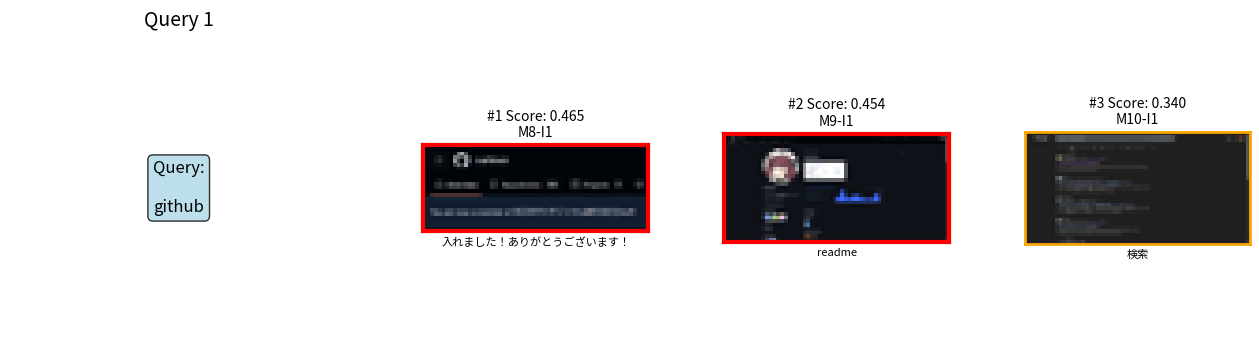

--------------------------------------------------------------------------------


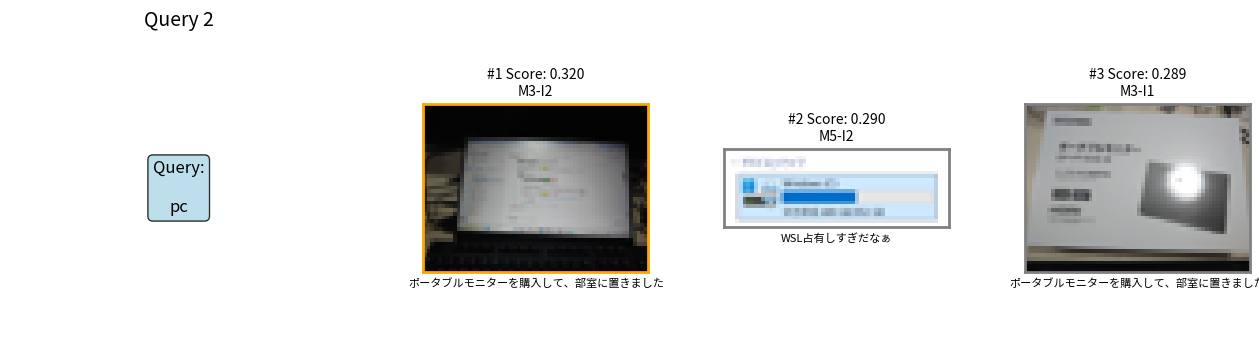

--------------------------------------------------------------------------------


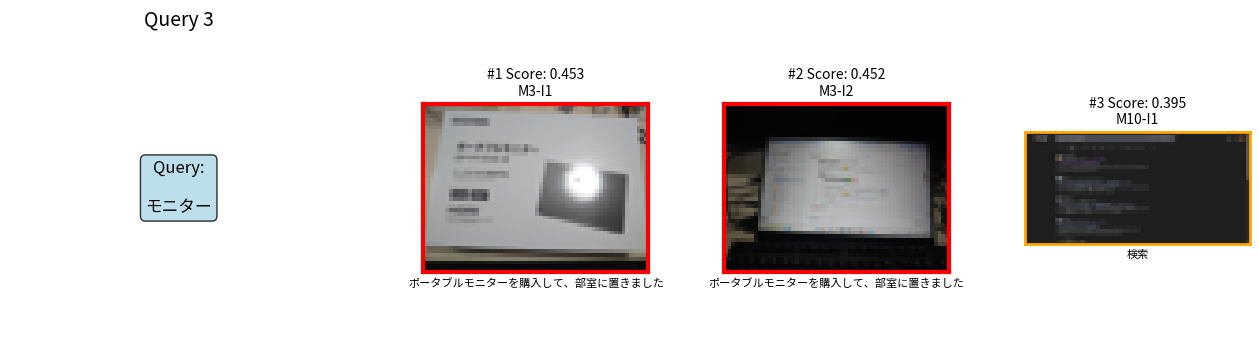

--------------------------------------------------------------------------------


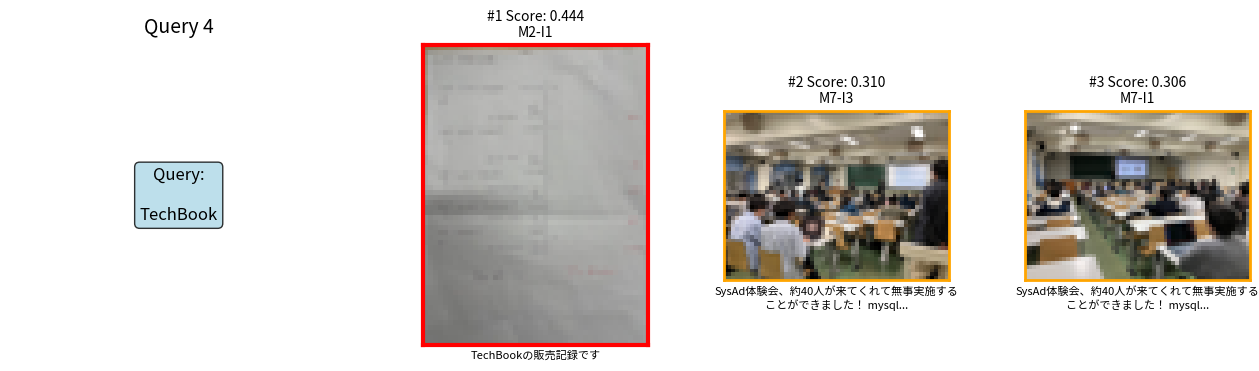

--------------------------------------------------------------------------------


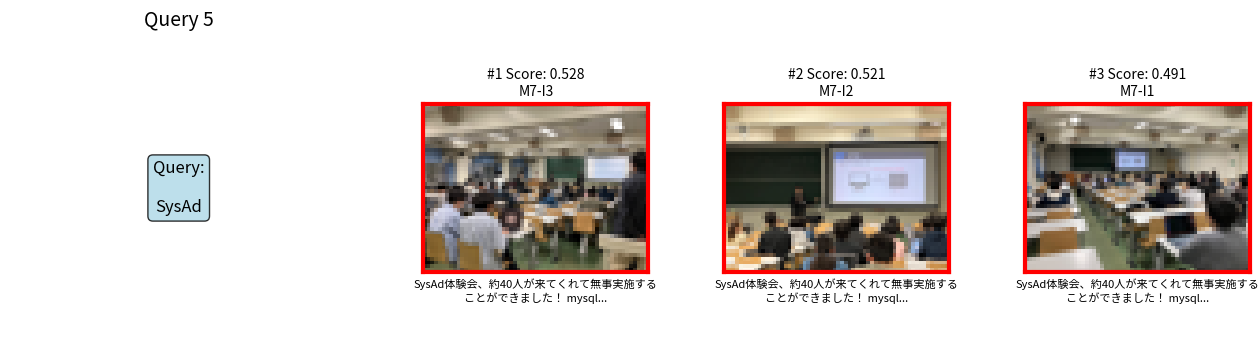

--------------------------------------------------------------------------------


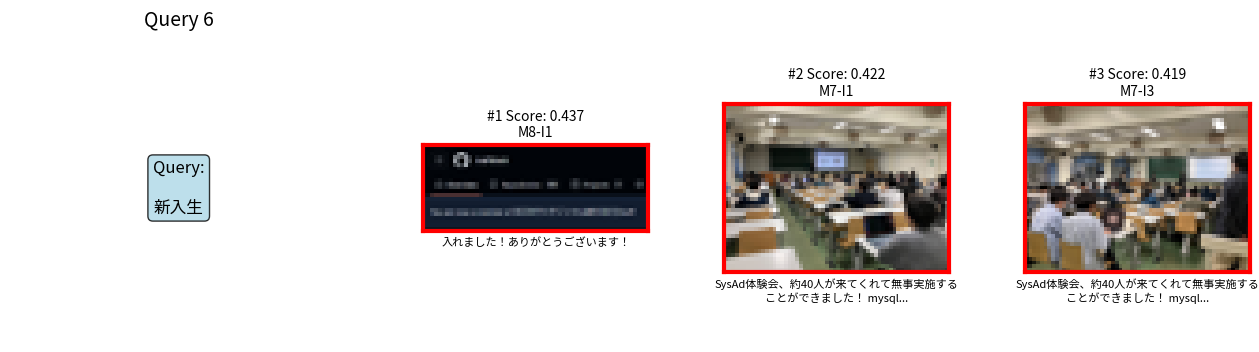

--------------------------------------------------------------------------------


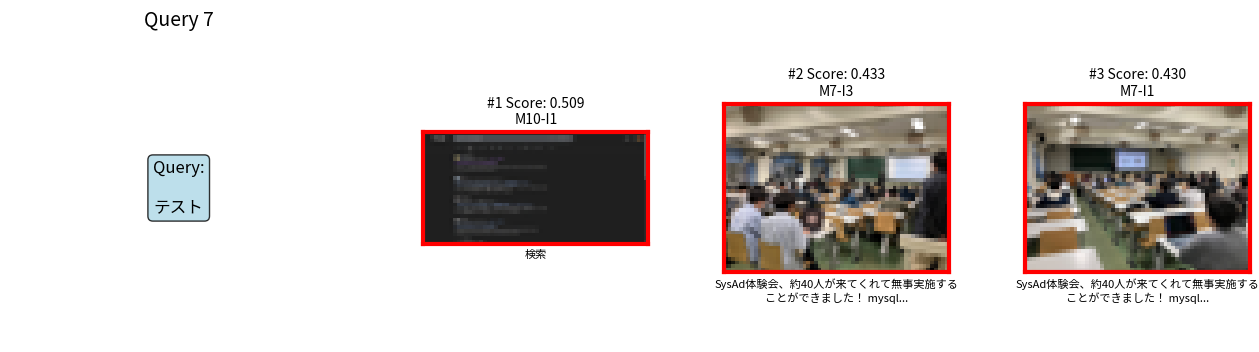

--------------------------------------------------------------------------------


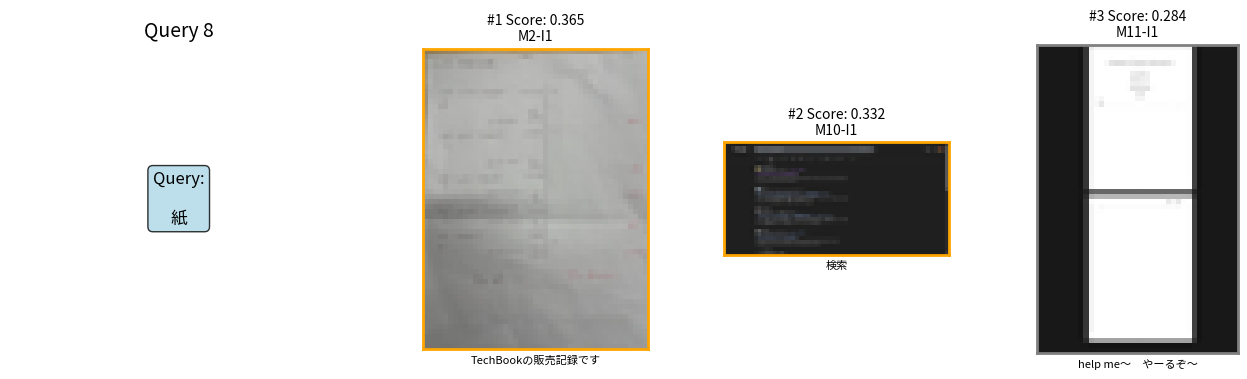

--------------------------------------------------------------------------------


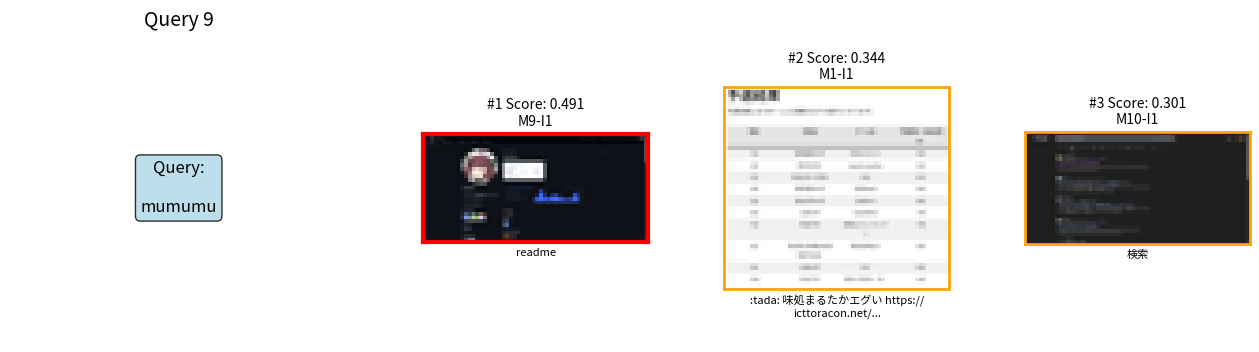

--------------------------------------------------------------------------------


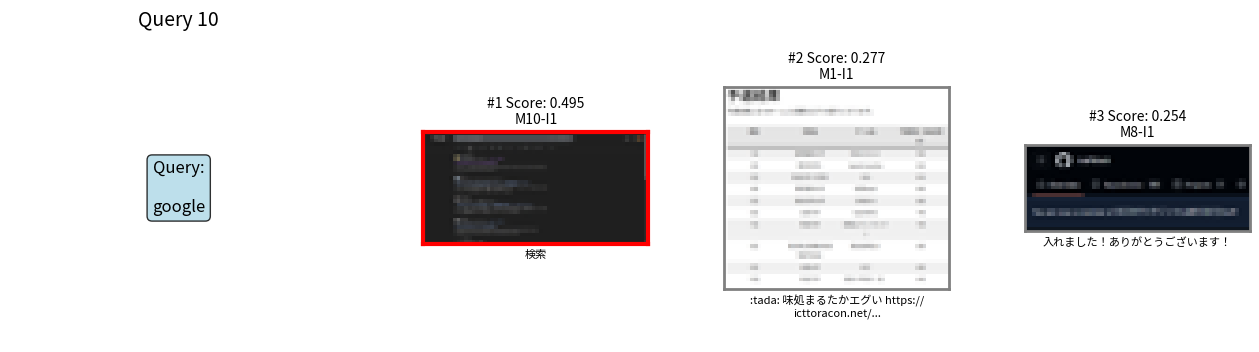

--------------------------------------------------------------------------------


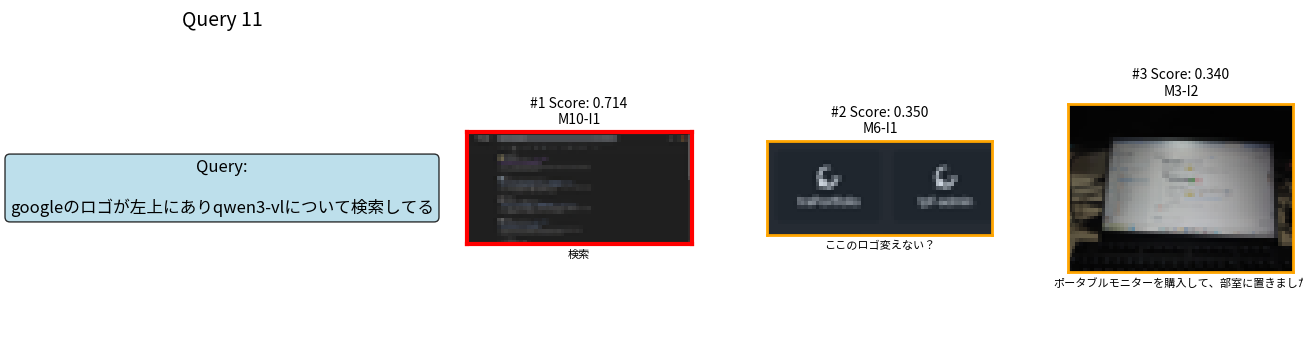

--------------------------------------------------------------------------------


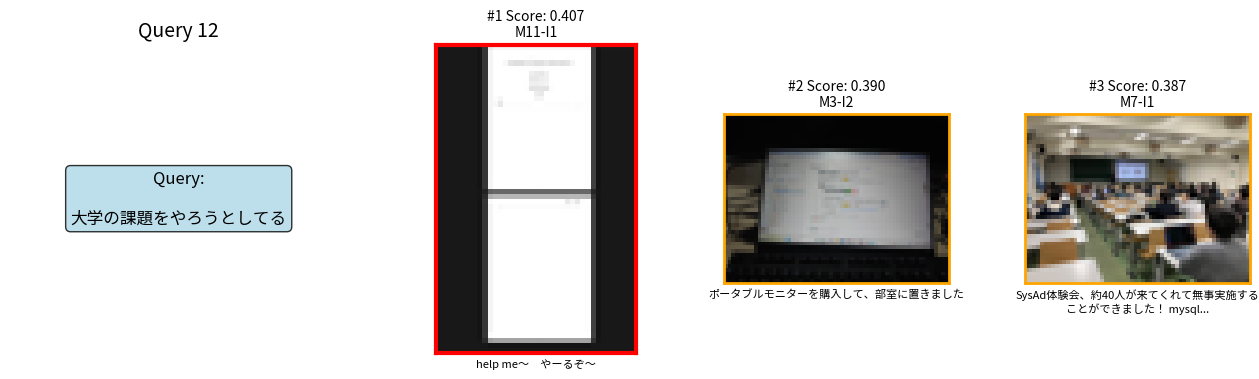

--------------------------------------------------------------------------------


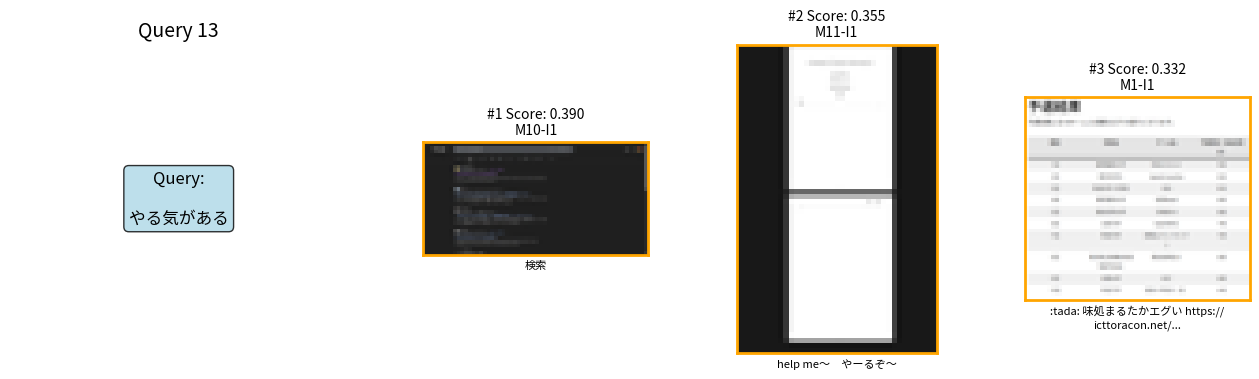

--------------------------------------------------------------------------------


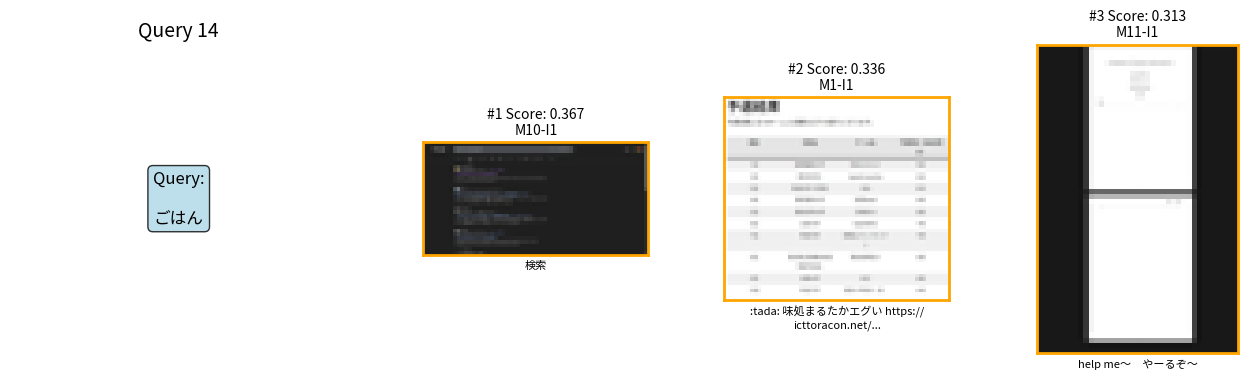

--------------------------------------------------------------------------------


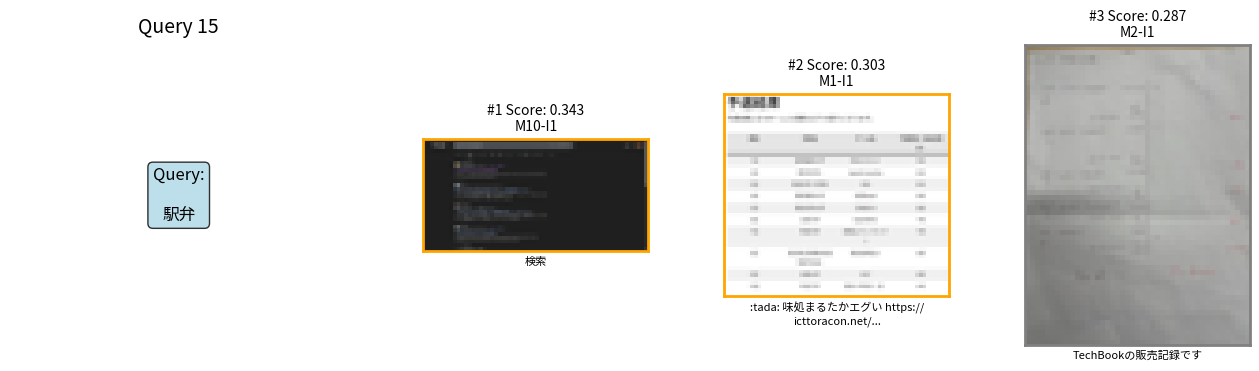

--------------------------------------------------------------------------------


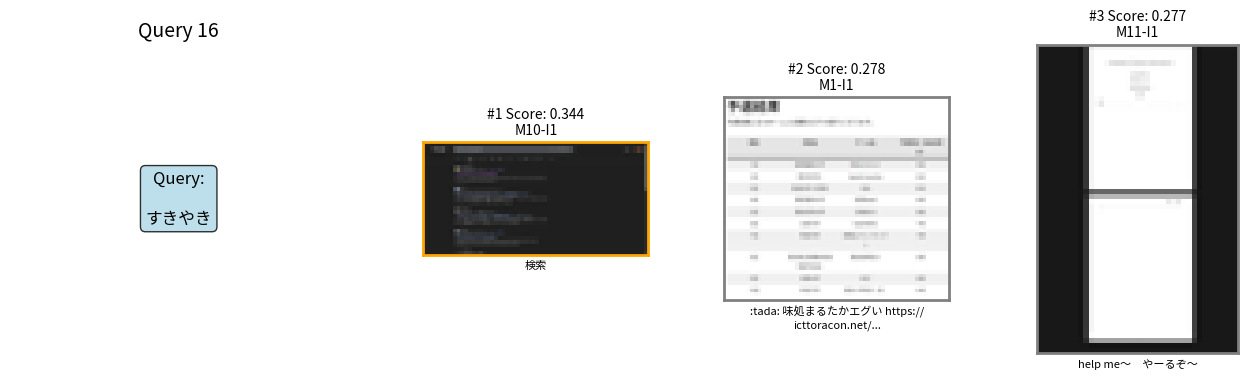

--------------------------------------------------------------------------------


In [44]:
# クエリごとの検索結果を見やすい表で表示
# 各クエリに対して、類似度が高いドキュメントを画像とテキストと一緒に表示

import matplotlib.gridspec as gridspec
import textwrap

# クエリとドキュメントの類似度（セル9で計算済み）
query_doc_similarity = similarity_scores.cpu().numpy()

# 各クエリに対してTop-3のドキュメントを表示
top_k = 3

for q_idx, query_text in enumerate(query_texts):
    # このクエリに対する類似度
    scores = query_doc_similarity[q_idx]
    
    # Top-kのインデックスを取得
    top_indices = np.argsort(scores)[::-1][:top_k]
    
    # 図を作成
    fig = plt.figure(figsize=(16, 4))
    gs = gridspec.GridSpec(1, top_k + 1, width_ratios=[1.5] + [1] * top_k, wspace=0.3)
    
    # クエリを左端に表示
    ax_query = fig.add_subplot(gs[0, 0])
    ax_query.text(0.5, 0.5, f"Query:\n\n{query_text}", 
                  ha='center', va='center', fontsize=12,
                  wrap=True, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    ax_query.axis('off')
    ax_query.set_title(f"Query {q_idx + 1}", fontsize=14, fontweight='bold')
    
    # Top-kのドキュメントを右に表示
    for rank, doc_idx in enumerate(top_indices):
        ax = fig.add_subplot(gs[0, rank + 1])
        
        # サムネイル画像を表示
        if doc_idx < len(thumbnails):
            ax.imshow(thumbnails[doc_idx])
        
        # テキストを短縮
        msg_idx = doc_to_msg_idx[doc_idx]
        doc_text = messages[msg_idx][:40] + "..." if len(messages[msg_idx]) > 40 else messages[msg_idx]
        
        # スコアとテキストをタイトルに
        score = scores[doc_idx]
        ax.set_title(f"#{rank+1} Score: {score:.3f}\n{labels[doc_idx]}", fontsize=10)
        ax.set_xlabel(textwrap.fill(doc_text, width=25), fontsize=8)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        
        # スコアに応じて枠の色を変える
        for spine in ax.spines.values():
            spine.set_color('red' if score > 0.4 else 'orange' if score > 0.3 else 'gray')
            spine.set_linewidth(3 if score > 0.4 else 2)
    
    plt.tight_layout()
    plt.show()
    print("-" * 80)
